# Tarea Semanal 2: Algoritmo para calcular la DFT
**Autor:** Marco Trabattoni  
**Cátedra:** Procesamiento Digital de Señales - R6051  
**Docente:** Mariano Llamedo Soria
 
---
## 1. Introducción y Configuración
En esta sección se importan las librerías necesarias (`numpy` y `matplotlib.pyplot`) y se definen los parámetros globales de la simulación, y las funciones a utilizar durante la misma.

In [10]:
# Importación de módulos que utilizaremos en esta tarea semanal 2:
# Una vez invocadas estas funciones, podremos utilizar los módulos a través 
# del identificador que indicamos luego de "as". 
import numpy as np
import matplotlib.pyplot as plt

#%% PARÁMETROS DE LA SEÑAL SENOIDAL
fs = 1000          # Frecuencia de muestreo (Hz)
N = 1000           # Número de muestras
f0 = 10            # Frecuencia de la senoidal (Hz)

## 2. Definición de Funciones
A continuación, se definen las funciones para generar una señal **Senoidal**, y calcular la **DFT**. `MT_Senoidal` devuelve un vector de tiempo `tt` y un vector de amplitud `xx` de dimensiones $N \times 1$, mientras que la `mi_funcion_DFT` devuelve una matriz de números complejos `XX` de dimensiones $N \times 1$.

In [11]:
#%%  ALGORITMO DFT
def mi_funcion_DFT(xx):
    N = len(xx)
    n = np.arange(N)
    k = n.reshape((N, 1))
    
    matriz_exponencial = np.exp(-2j * np.pi * k * n / N)
    
    XX = np.dot(matriz_exponencial, xx)
    
    return XX

#%%  Definicion de mi señal senoidal (TS1)

def MT_Senoidal(vmax=1, dc=0, ff=1, ph=0, nn=100, fs=100):
    
    """
    Genera una señal senoidal con los siguientes argumentos:
        
    vmax -- Amplitud máxima (Volts)
    dc   -- Valor medio (Volts)
    ff   -- Frecuencia de la senoidal (Hz)
    ph   -- Fase (Radianes)
    nn   -- Cantidad de muestras (#)
    fs   -- Frecuencia de muestreo (Hz)
    
    Retorna:
    tt   -- Vector de tiempo (Nx1)
    xx   -- Vector de amplitud (Nx1)
    
    """
    
    # Calculamos el intervalo entre muestras (periodo de muestreo)
    ts = 1/fs
    
    # Generamos el vector de tiempo tt
    tt = np.arange(0.0, N*ts, ts)
    
    # Generamos el vector de señal xx
    xx = vmax * np.sin(2 * np.pi * ff * tt + ph) + dc
    
    return tt, xx

## 3. Generación y Visualización de análisis 
Se procede a instanciar la senoidal y analizar su DFT, utilizando las funciones definidas anteriormente, para luego graficarlas y verificar su correcto funcionamiento en el dominio del tiempo y frecuencia. 

Además, en la sección **BONUS** se repiten las mismas experiencias con la transformada rápida de Fourier (DFT rápida se llama FFT) y se calcula la DFT de una señal aleatoria, de ruido uniforme con varianza `σ² = 4`.

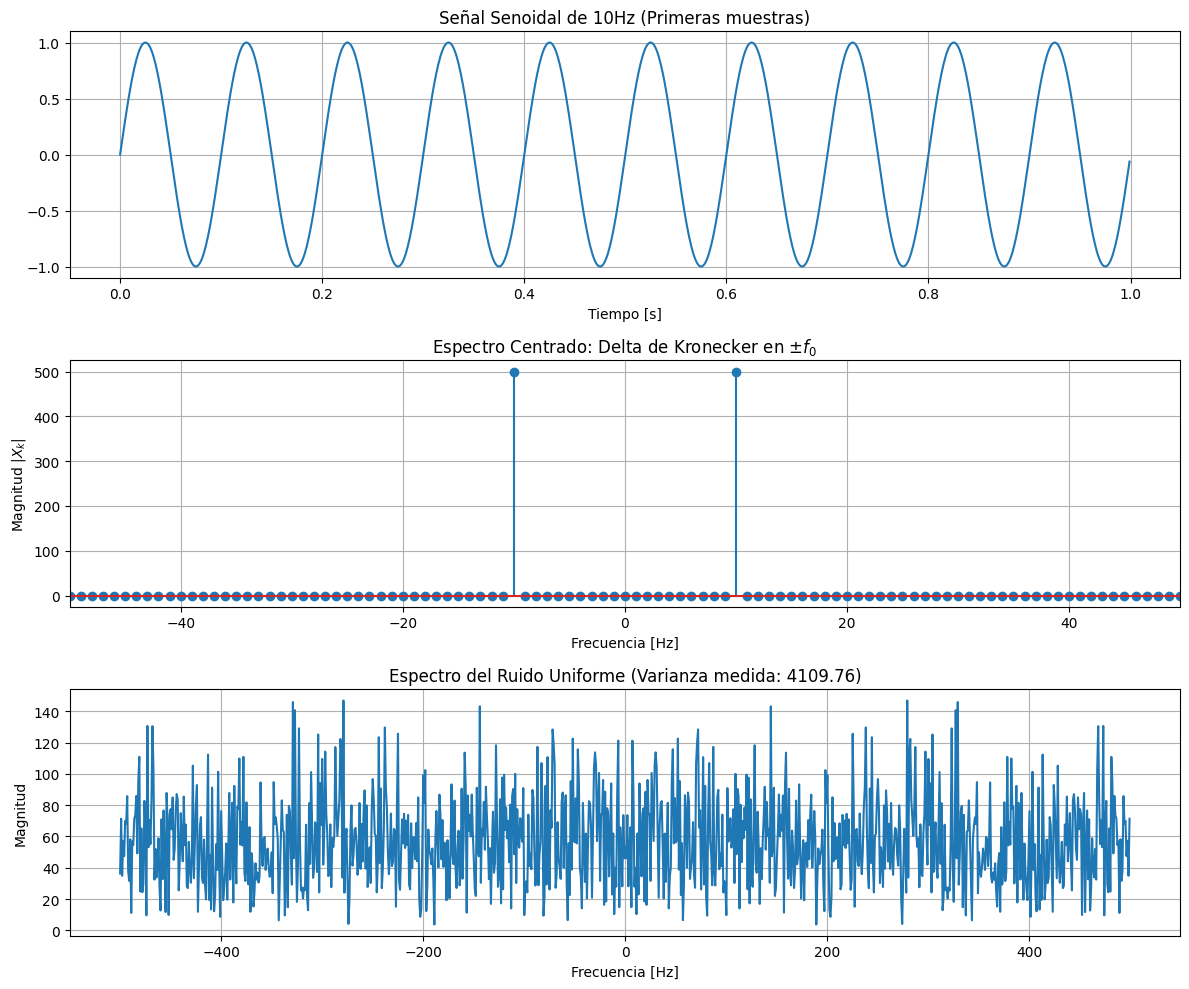

In [12]:
#%% GENERACION DE LA SENOIDAL
tt, xx = MT_Senoidal(vmax=1, dc=0, ff=f0, ph=0, nn=N, fs=fs)

#%% CÁLCULO DE LA DFT
XX = mi_funcion_DFT(xx)
#%% CÁLCULO DE LA FFT
XX = np.fft.fftshift(XX)
frec = np.fft.fftshift(np.fft.fftfreq(N, 1/fs))

#%% BONUS
L = np.sqrt(48)
xx_ruidosa = np.random.uniform(-L/2, L/2, N)
xx_ruidosa = np.fft.fftshift(mi_funcion_DFT(xx_ruidosa))

#%% GRAFICOS
# Senoidal
plt.figure(figsize=(12, 10))
plt.subplot(3, 1, 1)
plt.plot(tt, xx)
plt.title(f"Señal Senoidal de {f0}Hz (Primeras muestras)")
plt.xlabel("Tiempo [s]")
plt.grid(True)

# Espectro de la senoidal (Deltas de Kronecker)
plt.subplot(3, 1, 2)
plt.stem(frec, np.abs(XX))
plt.title("Espectro Centrado: Delta de Kronecker en $\pm f_0$")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud $|X_k|$")
plt.xlim(-50, 50) # Zoom para ver bien las deltas
plt.grid(True)

# Espectro del Ruido Uniforme
plt.subplot(3, 1, 3)
plt.plot(frec, np.abs(xx_ruidosa))
plt.title(f"Espectro del Ruido Uniforme (Varianza medida: {np.var(xx_ruidosa):.2f})")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud")
plt.grid(True)

plt.tight_layout()
plt.show()